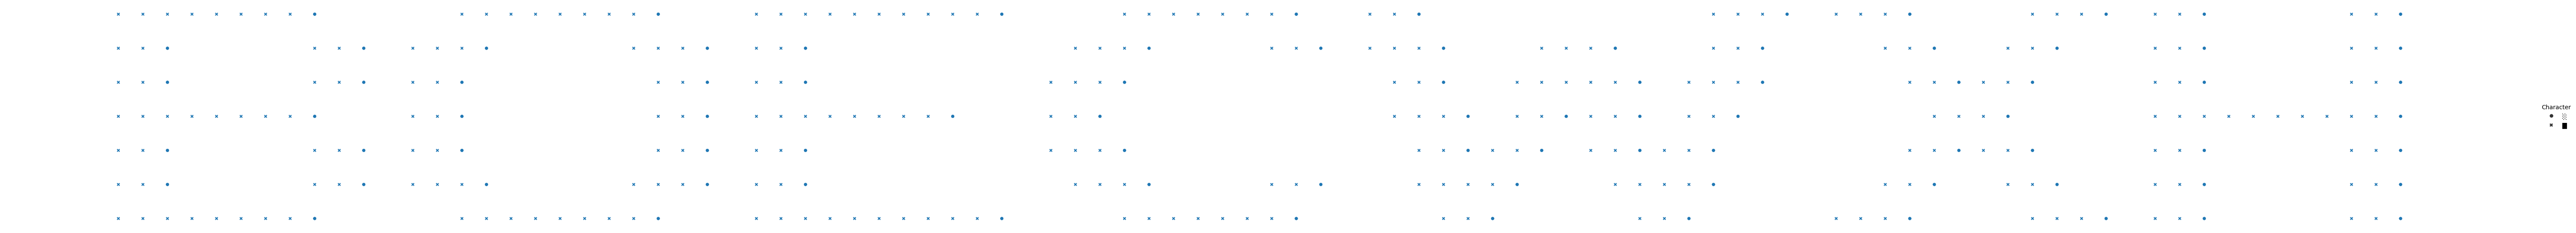

In [ ]:
# This program reads a table data from a google doc, and then plot the data in a fixed-width that shows a secret message.
def get_my_secret_message(request_url):
 table_data=pd.read_html(request_url,encoding='utf-8')[0]
 my_df = DataFrame(table_data)
 #with pd.option_context('display.max_rows', None,):
 #print(my_df)

 my_df.columns=my_df. iloc[0]
 my_df = my_df.iloc[1:]
 my_df[int_cols] = my_df[int_cols].apply(pd.to_numeric)
 #print(df_updated)

 g = sns.relplot(data=my_df, x='x-coordinate', y='y-coordinate', kind='scatter', style='Character', height=6, aspect=10)
 g.set(xticks=[], yticks=[], xlabel=None, ylabel=None)
 g.despine(left=True, bottom=True)
 return g

#get_my_secret_message('https://docs.google.com/document/d/e/2PACX-1vSHesOf9hv2sPOntssYrEdubmMQm8lwjfwv6NPjjmIRYs_FOYXtqrYgjh85jBUebK9swPXh_a5TJ5Kl/pub?embedded=true')

get_my_secret_message('https://docs.google.com/document/d/e/2PACX-1vQGUck9HIFCyezsrBSnmENk5ieJuYwpt7YHYEzeNJkIb9OSDdx-ov2nRNReKQyey-cwJOoEKUhLmN9z/pub')

In [11]:
print(df.index)
print(df['x-coordinate'].value_counts())
print(df['y-coordinate'].max())

RangeIndex(start=0, stop=332, step=1)
x-coordinate
87    7
52    7
1     7
67    7
53    7
     ..
18    2
75    2
25    2
59    2
50    1
Name: count, Length: 84, dtype: int64
6


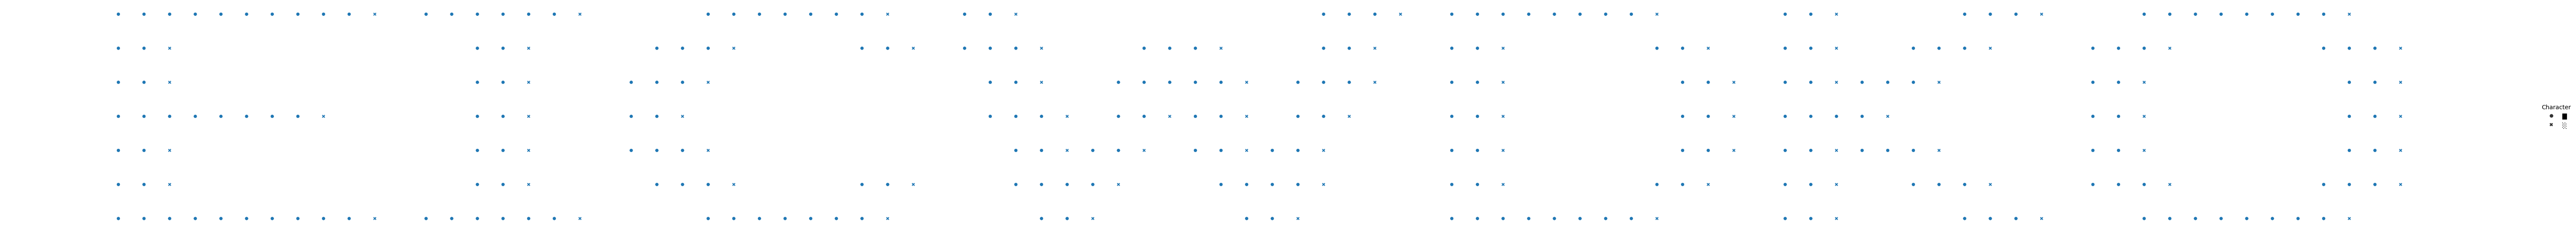

In [12]:
g = sns.relplot(data=df, x='x-coordinate', y='y-coordinate', kind='scatter', style='Character', height=6, aspect=10)
g.set(xticks=[], yticks=[], xlabel=None, ylabel=None)
g.despine(left=True, bottom=True)

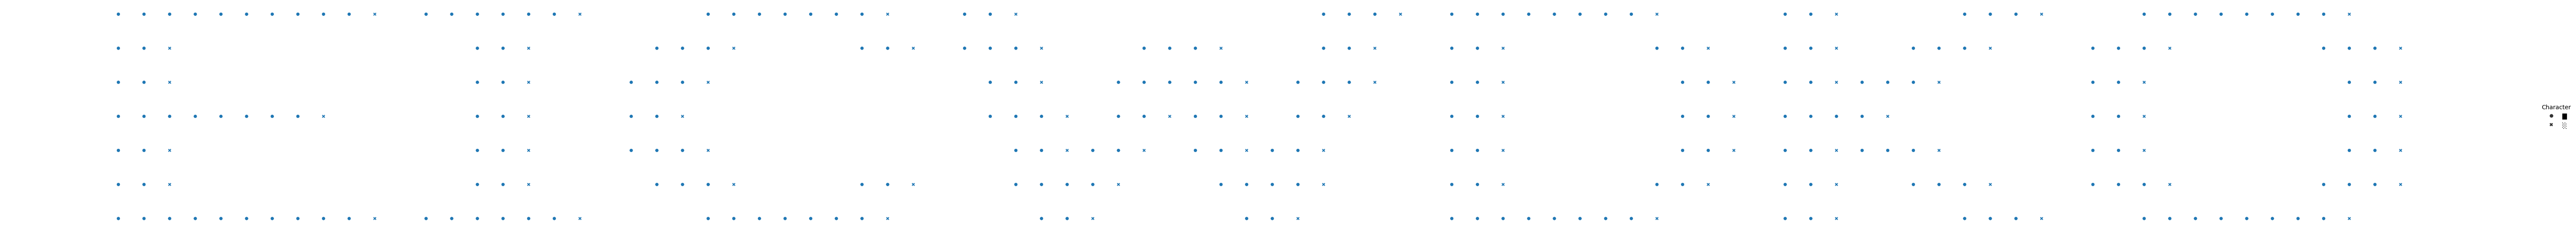

In [13]:
# Nazrul code
g = sns.relplot(data=df_updated, x='x-coordinate', y='y-coordinate', kind='scatter', style='Character', height=6, aspect=10)
g.set(xticks=[], yticks=[], xlabel=None, ylabel=None)
g.despine(left=True, bottom=True)

In [14]:
def get_secret_message(url):
  response = requests.get(url)
  html_soup = Soup(response.text, 'html.parser')

  tables = html_soup.find_all('table')
  len(tables)

  msg_table = tables[0]
  rows = msg_table.find_all('tr')
  def parse_row(row):
    return [str(x.string) for x in row.find_all('td')]
  list_of_parsed_rows = [parse_row(row) for row in rows[1:]]
  df = DataFrame(list_of_parsed_rows)
  df.columns = [str(x.string) for x in rows[0].find_all('td')]
  int_cols = ['x-coordinate', 'y-coordinate']
  df[int_cols] = df[int_cols].apply(pd.to_numeric)
  g = sns.relplot(data=df, x='x-coordinate', y='y-coordinate', kind='scatter', style='Character', height=6, aspect=10)
  g.set(xticks=[], yticks=[], xlabel=None, ylabel=None)
  g.despine(left=True, bottom=True)
  return g

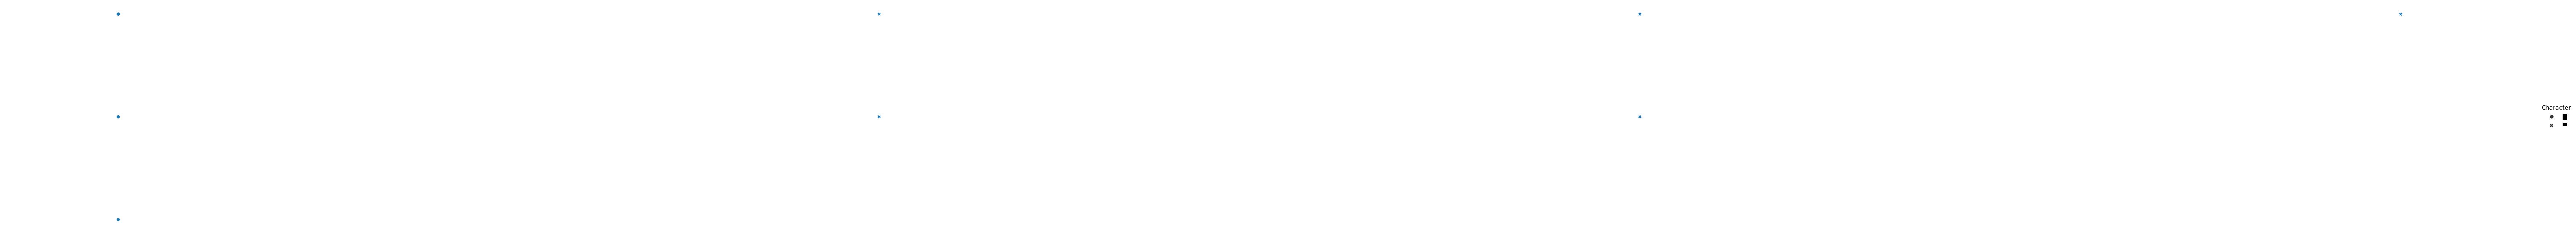

In [15]:
#get_secret_message('https://docs.google.com/document/d/e/2PACX-1vSHesOf9hv2sPOntssYrEdubmMQm8lwjfwv6NPjjmIRYs_FOYXtqrYgjh85jBUebK9swPXh_a5TJ5Kl/pub?embedded=true')
get_secret_message('https://docs.google.com/document/d/e/2PACX-1vRMx5YQlZNa3ra8dYYxmv-QIQ3YJe8tbI3kqcuC7lQiZm-CSEznKfN_HYNSpoXcZIV3Y_O3YoUB1ecq/pub')